# Multi-GPU LLM Training: DeepSpeed ZeRO & Distributed Training

## 📚 Table of Contents
1. [Introduction to Multi-GPU Training](#intro)
2. [Challenges in Distributed Training](#challenges)
3. [ZeRO Optimization](#zero)
4. [Configuration Deep Dive](#config)
5. [Understanding Mixed Precision: BF16 vs FP16](#mixed-precision)
6. [Implementation Examples](#implementation)
7. [Interview Q&A - Real Scenarios](#interview)
8. [Advanced Topics](#advanced)
9. [Troubleshooting Common Issues](#troubleshooting)
10. [Visual Diagrams](#visual-diagrams)
11. [Quick Reference Code](#quick-reference)
12. [FSDP vs DeepSpeed ZeRO Comparison](#fsdp-vs-deepspeed)
13. [Rapid-Fire Interview Q&A](#rapid-fire)

---

## Learning Objectives

By the end of this notebook, you will:
- Understand the challenges of training large language models on multiple GPUs
- Master ZeRO optimization stages and configurations
- Implement DeepSpeed configurations for real-world scenarios
- Answer common interview questions about distributed training
- Troubleshoot multi-GPU training issues
- Compare FSDP and DeepSpeed ZeRO for real-world decision-making

---

## Prerequisites

- Understanding of PyTorch and neural network training
- Basic knowledge of distributed computing
- Familiarity with model optimization techniques


## 🔧 **Challenges of Distributed LLM Training on Multi-GPU Clusters**

### ✅ **Single GPU Recap**:
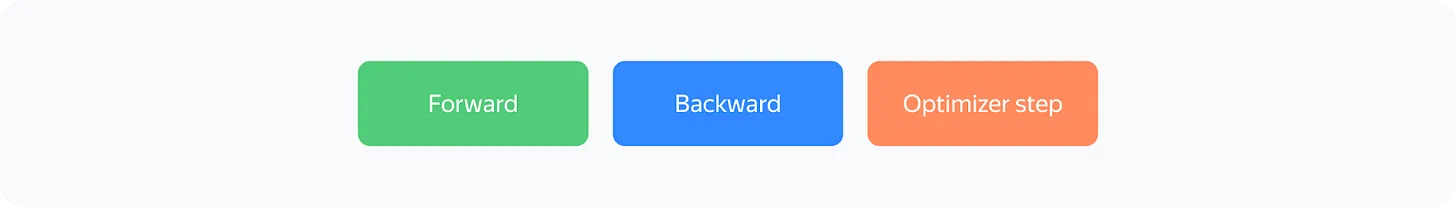
On a single GPU:

1.  Forward pass → compute outputs and loss.
    
2.  Backward pass → compute gradients.
    
3.  Optimizer step → update weights.
    

### 🔄 **When Scaling to Multiple GPUs (Distributed Data Parallel - DDP)**:
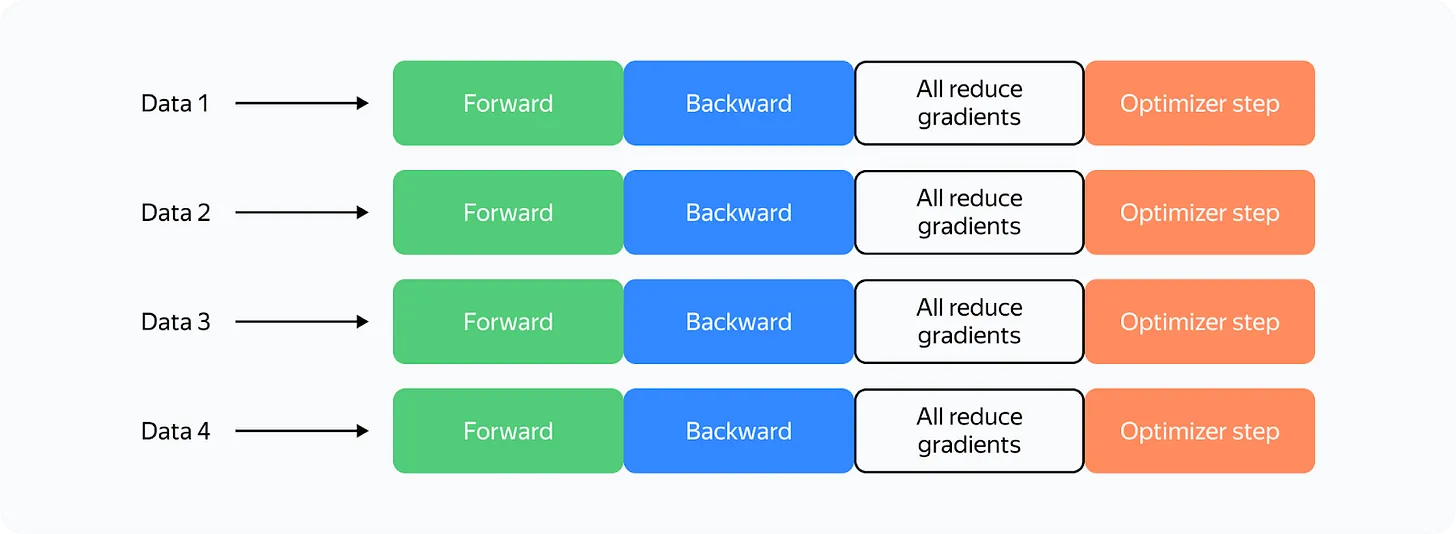
Each GPU processes part of the batch, and then:

-   Gradients are synchronized across GPUs using **`all_reduce`**.
    
-   Model weights are kept **identical** on each GPU.
    
-   Optimizer states and gradients are **duplicated** on each GPU.
    

----------

## ❌ **Main Issues with Multi-GPU Training**
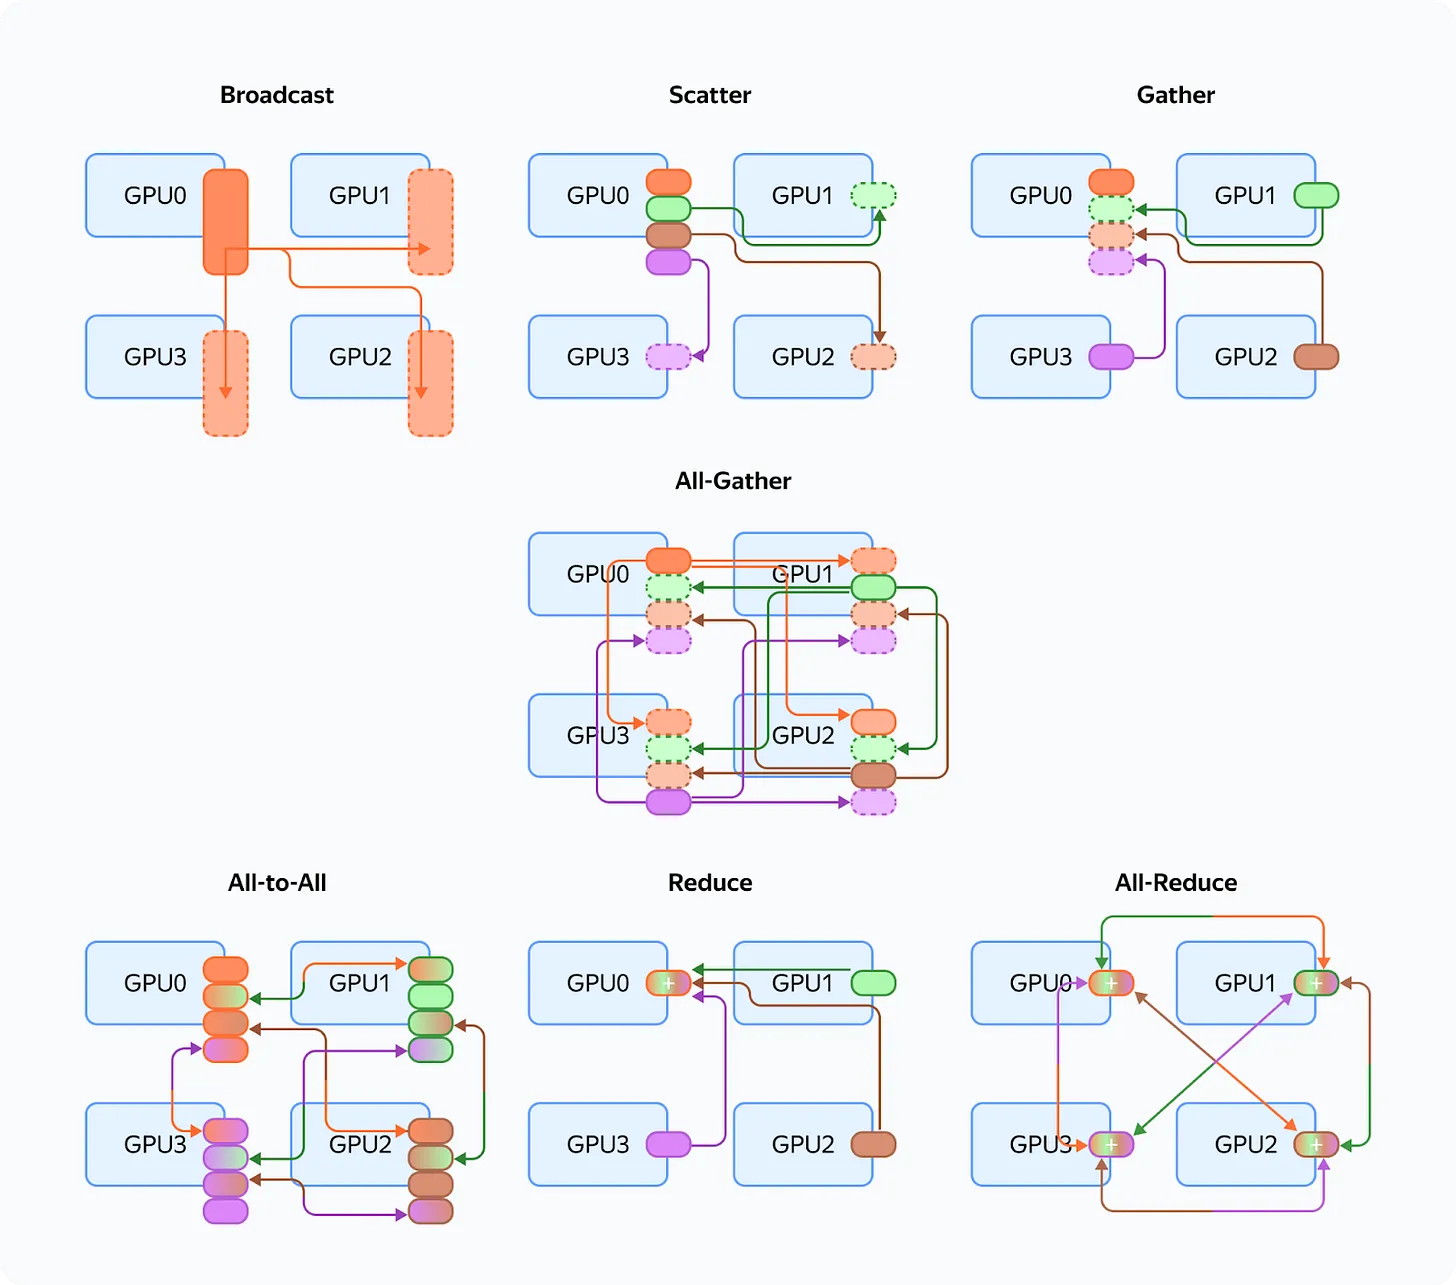
### 1. 🚦 **Communication Overhead**

-   **`all_reduce`** is fast, but **costly at scale**.
    
-   In **fp16**, for LLaMA-70B:
    
    -   Gradients = 140 GB (1x)
        
    -   All-reduce sends **280 GB per iteration**.
        
-   This becomes a **bottleneck**—especially in inter-node communication.
    

### 2. 💾 **Memory Duplication**

Each GPU stores:

-   **Full model weights**
    
-   **Gradients**
    
-   **Optimizer states (e.g., Adam uses momentum and variance)**
    

💡 For LLaMA-70B with mixed precision:

-   Needs **>1 TB memory**
    
-   A single A100 GPU has only **80 GB VRAM**
    

Thus:

> We **can't even fit** the model using naïve DDP—even with 4 GPUs.

----------


## 🔧 Detailed Configuration Explanation

### DeepSpeed ZeRO Configuration Breakdown

Let's understand each configuration parameter in detail:

#### 1. **Basic ZeRO Configuration**

```json
{
  "zero_optimization": {
    "stage": 1,  // ZeRO stage: 1, 2, or 3
    "allgather_partitions": true,
    "allgather_bucket_size": 5e8,
    "overlap_comm": false,
    "reduce_scatter": true,
    "reduce_bucket_size": 5e8,
    "contiguous_gradients": true
  }
}
```

**Parameter Explanations:**

- **`stage`**: ZeRO optimization stage (1, 2, or 3)
  - Stage 1: Optimizer state partitioning (4x memory reduction)
  - Stage 2: + Gradient partitioning (8x memory reduction)
  - Stage 3: + Parameter partitioning (linear memory reduction with GPU count)

- **`allgather_partitions`**: Enable parameter all-gather for forward pass (required for Stage 3)

- **`allgather_bucket_size`**: Size of the all-gather communication bucket (500MB default)

- **`overlap_comm`**: Overlap computation and communication (improves throughput)

- **`reduce_scatter`**: Use reduce-scatter for gradient reduction (more efficient than all-reduce)

- **`reduce_bucket_size`**: Size of the reduce-scatter communication bucket

- **`contiguous_gradients`**: Copy gradients to contiguous memory before reduction

#### 2. **Offloading Configuration**

```json
{
  "zero_optimization": {
    "stage": 3,
    "offload_optimizer": {
      "device": "cpu",        // or "none"
      "pin_memory": true,
      "fast_init": false
    },
    "offload_param": {
      "device": "cpu",        // or "none"
      "pin_memory": true,
      "max_in_cpu": 1e9       // Max parameters in CPU (1B default)
    }
  }
}
```

**Why Offload?**

- **CPU RAM is cheaper**: Usually 4-8x more capacity than GPU VRAM
- **NVMe storage**: Can offload to disk for extremely large models
- **Trade-off**: Communication overhead between CPU/GPU

**When to Use:**
- Model doesn't fit on GPU even with ZeRO Stage 3
- You have excess CPU RAM and limited GPU VRAM
- Training billion+ parameter models on consumer hardware

#### 3. **Gradient Accumulation & Micro-batching**

```json
{
  "gradient_accumulation_steps": 4,
  "train_micro_batch_size_per_gpu": 2,
  "gradient_clipping": 1.0
}
```

**Concept**: 
- Effective batch size = `train_micro_batch_size_per_gpu × gradient_accumulation_steps × num_gpus`
- Example: `2 × 4 × 8 = 64` samples per update

**Gradient Clipping**: Prevents exploding gradients in large models


ZeRO’s main concept is to `leverage memory redundancy` in **data-parallel training** and enhance `inter-GPU communication` efficiency for improved throughput, with a trade-off of` increased communication volume depending` on the stage. ZeRO consists of two key components:

-   ZeRO-DP (Data Parallelism)
-   ZeRO-R (Residual Memory)

![](https://archive.is/WRg2M/c89877c155a2204041e2406c5f254baccb16ac50.webp)

Figure 2: source:  [https://www.microsoft.com/en-us/research/blog/zero-deepspeed-new-system-optimizations-enable-training-models-with-over-100-billion-parameters/](https://archive.is/o/WRg2M/https://www.microsoft.com/en-us/research/blog/zero-deepspeed-new-system-optimizations-enable-training-models-with-over-100-billion-parameters/)

As depicted in Figure , ZeRO has three main optimisation stages, which correspond to the partitioning of optimiser states, gradients, and parameters. When enabled cumulatively:

_1. **Optimizer State** Partitioning (Pos) — 4x memory reduction, same communication volume as data parallelism_

_2. **Add Gradient Partitioning** (Pos+g) — 8x memory reduction, same communication volume as data parallelism_

_3. Add **Parameter Partitioning** (Pos+g+p) — Memory reduction is linear with data parallelism degree Nd._

ZeRO eliminates memory redundancies and makes the full aggregate memory capacity of a cluster available. The DeepSpeed team has also put out more compelling —  **ZeRO-Offload**/Infinity (offloading computation to CPU/ NVMe disk) and ZeRO++ (with flexible multi-node training and quantized weights).

ZeRO (Zero Redundancy Optimizer) is a breakthrough approach that tackles the key inefficiencies in distributed deep learning by addressing the memory overhead inherent in traditional data parallelism and the intricate dependencies typical of model parallelism. Instead of replicating all model states (parameters, gradients, and optimizer states) across every process, ZeRO smartly partitions these states across devices. This design allows for the efficient training of very large models without the crippling memory redundancy or communication bottlenecks.

Below is a detailed breakdown of how ZeRO overcomes the limitations and what each optimization stage entails:

----------

### 1. The Challenge with Traditional Parallelism

-   **Data Parallelism:**
    
    -   **Pros:** Easy to scale; each GPU has a copy of the complete model and processes a different mini-batch of data.
    -   **Cons:** Every GPU holds a full replica of model parameters, gradients, and optimizer states. This replication leads to a massive memory overhead—a severe constraint when training extremely large models.
-   **Model Parallelism:**
    
    -   **Pros:** Splits model parameters across GPUs, reducing per-device memory usage.
    -   **Cons:** Often suffers from complex inter-device communications and fine-grained partitioning, which can hamper computational efficiency.

----------



----------

### 3. Stages of ZeRO Optimization

#### **Stage 1: Partitioning Optimizer States**

-   **What Happens:**  
    Optimizer states (for instance, in the Adam optimizer, these include the 32-bit weights along with the first and second moment estimates) are partitioned so that each process holds only a fraction of these states.
    
-   **Benefit:**  
    Each GPU only maintains and updates its assigned slice of the optimizer state, drastically reducing redundant memory usage across processes.
    
- Partitions optimizer states across GPUs instead of replicating them.
- Reduces memory redundancy without impacting gradient or parameter storage.
- Each GPU holds a shard of the optimizer states.

```json
{
  "zero_optimization": {
    "stage": 1
  },
  "gradient_accumulation_steps": 1,
  "train_micro_batch_size_per_gpu": 1,
  "gradient_clipping": 1.0,
  "fp16": {
    "enabled": true
  }
}
```

- You can offload optimizer states to CPU (works in stages 1–3):  

#### **Stage 2: Partitioning Gradients**

-   **What Happens:**  
    Instead of each device retaining the entire 32-bit gradient for all parameters, ZeRO partitions the gradients. Each process only keeps the gradients corresponding to its portion of the optimizer state.
    
-   **Benefit:**  
    This step further cuts down on memory consumption and ensures that gradient computations are distributed efficiently across devices.
 
- Partitions gradients across GPUs instead of storing full gradients on each.
- Enables larger batch sizes and models.

```json
{
  "zero_optimization": {
    "stage": 2
  },
  "gradient_accumulation_steps": 1,
  "train_micro_batch_size_per_gpu": 1,
  "gradient_clipping": 1.0,
  "fp16": {
    "enabled": true
  }
} 
```
#### **Stage 3: Partitioning Parameters**

-   **What Happens:**  
    ZeRO-3 takes the partitioning a step further by dividing the 16-bit model parameters themselves across devices. During the forward and backward passes, these parameters are collected and partitioned on the fly.
    
-   **Benefit:**  
    The model’s weight matrix, typically one of the largest components of memory use, no longer needs to be fully replicated. This enables the training of models that would otherwise be too large to fit into a single GPU’s memory.
    
- Partitions model parameters across GPUs.
- Minimizes GPU memory usage by sharding full model state: parameters, gradients, and optimizer states.
- Communication between GPUs ensures each device gets parameters it needs for forward/backward passes.

```json
{
  "zero_optimization": {
    "stage": 3,
    "offload_param": {
      "device": "cpu",
      "pin_memory": true
    },
    "offload_optimizer": {
      "device": "cpu",
      "pin_memory": true
    }
  },
  "gradient_accumulation_steps": 1,
  "train_micro_batch_size_per_gpu": 1,
  "gradient_clipping": 1.0,
  "fp16": {
    "enabled": true
  }
}

```
----------

### 4. ZeRO-Infinity: Beyond GPUs

-   **Infinity Offload Engine:**  
    ZeRO-3 has evolved to include an infinity offload engine, leading to what is known as **ZeRO-Infinity.** This feature further extends the capabilities by offloading parts of the model state not just to the CPU but also to NVMe storage.
    
-   **Benefit:**  
    Offloading to both CPU and NVMe allows for even greater memory savings, meaning models that exceed GPU memory limits can still be trained efficiently. This is particularly vital when working with extremely large models or in environments with limited GPU resources.
    

----------

### 5. Dynamic Communication Scheduling

-   **Role in ZeRO:**  
    Although model states are partitioned, ZeRO isn’t just about slicing up memory. It also incorporates a dynamic communication schedule that ensures the necessary state information is shared across devices when needed during training.
    
-   **Impact:**  
    This smart scheduling keeps the computational granularity and communication volume comparable to what you would expect from data parallelism. Essentially, it minimizes the communication overhead while still reaping the memory benefits of partitioning.
 

| Setup                   | Scenario                                      | Strategy                                                                           |
|-------------------------|-----------------------------------------------|------------------------------------------------------------------------------------|
| Single Node / Multi-GPU | Fits on single GPU                            | DistributedDataParallel or ZeRO                                                   |
| Single Node / Multi-GPU | Doesn’t fit on single GPU                     | PipelineParallel, ZeRO, or TensorParallel                                          |
| Single Node / Multi-GPU | Largest model layer doesn’t fit               | TensorParallel or ZeRO                                                             |
| Multi-node / Multi-GPU  | Fast inter-node connectivity (NVLink/NVSwitch)  | ZeRO or 3D parallelism (PipelineParallel, TensorParallel, DataParallel)            |
| Multi-node / Multi-GPU  | Slow inter-node connectivity                  | ZeRO or 3D parallelism (PipelineParallel, TensorParallel, DataParallel)            |

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/parallelism-deepspeed-3d.png)

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/parallelism-zero-dp-pp.png)
-  **F0, F1, F2, F3 (Forward Pass):**

- Here, **"F" stands for "Forward"**—the part where you process data through the layers.

- The number typically indicates *either* the order of the micro-batch or the stage at which it is processed in forward order.

-  **For example:**

-  **F0:** The first micro-batch begins processing at Stage 0 (the first station).

-  **F1:** As soon as Stage 0 finishes with F0, it can start processing the next micro-batch, F1, or F0 moves to Stage 1 while F1 begins at Stage 0.

- This staggered processing continues until the last stage gets its micro-batch, say F3 at Stage 3.

  

-  **B3, B2, B1, B0 (Backward Pass):**

- Here, **"B" stands for "Backward"**—this is when gradients (or errors) are calculated and sent back through the network.

- The numbering goes **in reverse** relative to the forward pass because the last stage starts the backward computation first.

-  **For example:**

-  **B3:** Once micro-batch F3 has finished the forward pass (at the last stage), it immediately starts the backward pass and is labeled B3.

-  **B2:** Then, the process continues backward: the output of Stage 2 gets processed as B2, and so on until B0 at Stage 0.
Stage 0      Stage 1      Stage 2      Stage 3
  |            
F0 ->        F1 ->         F2 ->         F3 ->
  |            
  | <--B0     | <--B1     | <--B2     | <--B3

-  **Multiple micro-batches are processed concurrently.**

-  **The idle time (bubbles) is minimized by careful scheduling.**

-  **The benefits of overlapping computation across different stages often outweigh the losses due to those bubbles.**

## 🎯 Interview Q&A: Real-World Scenarios

### Scenario 1: Training GPT-3 Scale Model

**Question**: "You need to train a 175B parameter model. You have 4 nodes, each with 8 A100 GPUs (80GB each). The model doesn't fit on a single GPU. How would you configure the training?"

**Answer**:

```python
# Configuration Strategy
config = {
    "zero_optimization": {
        "stage": 3,  # Partition all states
        "offload_optimizer": {
            "device": "cpu",
            "pin_memory": True
        },
        "offload_param": {
            "device": "cpu",
            "pin_memory": True
        },
        "overlap_comm": True,  # Hide communication latency
        "contiguous_gradients": True
    },
    "train_micro_batch_size_per_gpu": 1,
    "gradient_accumulation_steps": 32,  # Large effective batch
    "gradient_clipping": 1.0,
    "fp16": {
        "enabled": True,
        "loss_scale": 0,
        "loss_scale_window": 1000
    },
    "wall_clock_breakdown": True
}
```

**Explanation**:
- **ZeRO Stage 3**: With 32 GPUs, we get ~5.5B parameters per GPU
- **CPU Offloading**: Handles remaining memory pressure
- **Micro-batch size = 1**: Maximum memory efficiency
- **Gradient accumulation**: Maintains large effective batch size
- **FP16**: Reduces memory and speeds up computation

**Memory Calculation**:
- Model parameters (FP16): 175B × 2 bytes = 350 GB
- With ZeRO-3 + 32 GPUs: 350GB / 32 = ~11 GB per GPU
- Optimizer states offloaded to CPU: Saves ~44 GB per GPU
- Activations: ~10-20 GB per GPU (depends on sequence length)

---

### Scenario 2: Budget-Constrained Training

**Question**: "You need to train a 7B parameter model but only have 2x RTX 3090 (24GB each). Design a working configuration."

**Answer**:

```python
# Strategy: ZeRO Stage 3 + CPU Offloading + Gradient Checkpointing
config = {
    "zero_optimization": {
        "stage": 3,
        "offload_optimizer": {
            "device": "cpu",
            "pin_memory": True
        },
        "offload_param": {
            "device": "cpu",
            "pin_memory": True
        }
    },
    "train_micro_batch_size_per_gpu": 1,
    "gradient_accumulation_steps": 8,
    "gradient_checkpointing": True,  # Critical for memory savings
    "fp16": {
        "enabled": True
    },
    "activation_checkpointing": {
        "partition_activations": True,
        "cpu_checkpointing": True  # Offload activations too
    }
}
```

**Key Techniques**:
1. **Gradient Checkpointing**: Reduces activation memory by 50-70%
2. **CPU Offloading**: Stores parameters and optimizer states in RAM
3. **Micro-batch = 1**: Minimum memory footprint
4. **Small sequence length**: Use 512 instead of 2048 tokens

**Memory Breakdown**:
- Model (FP16): 7B × 2 = 14 GB → Split across 2 GPUs = 7 GB each
- Gradients: ~7 GB → Split = 3.5 GB each
- Activations (with checkpointing): ~8 GB per GPU
- Total: ~18.5 GB per GPU ✅ (Fits in 24GB!)

---

### Scenario 3: Communication Bottleneck

**Question**: "Your distributed training is slow due to high communication overhead. What optimizations would you apply?"

**Answer**:

```python
config = {
    "zero_optimization": {
        "stage": 2,  # Lower stage = less communication
        "overlap_comm": True,  # Key optimization!
        "contiguous_gradients": True,
        "reduce_bucket_size": 1e8,  # Larger buckets = fewer calls
        "allgather_partitions": False
    },
    "communication_data_type": "fp16",  # Reduce comm. size
    "comms_logger": {
        "enabled": True,
        "verbose": False
    }
}
```

**Additional Optimizations**:

1. **Overlap Communication**: Run computation and communication in parallel
2. **Reduce bucket size**: Fewer, larger transfers
3. **Communication dtype**: FP16 instead of FP32 for gradients
4. **Tensor Parallelism**: Instead of ZeRO-3, use TP for certain layers
5. **Pipeline Parallelism**: Break model into stages

**Expected Speedup**: 30-50% improvement in throughput

---

### Scenario 4: Mixed Precision Training Issues

**Question**: "You're experiencing NaN losses with FP16 training. How do you debug and fix this?"

**Answer**:

```python
# Step 1: Enable detailed logging
config = {
    "fp16": {
        "enabled": True,
        "loss_scale": 0,  # Auto loss scaling
        "loss_scale_window": 1000,
        "initial_scale_power": 16,
        "hysteresis": 2,
        "min_loss_scale": 1
    },
    "wall_clock_breakdown": True,
    "tensorboard": {
        "enabled": True,
        "output_path": "./logs",
        "job_name": "debug_run"
    }
}
```

**Debugging Steps**:

1. **Check gradient norms**:
```python
import torch
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

2. **Monitor loss scale**:
```python
if torch.isnan(loss):
    print(f"NaN detected! Loss scale: {trainer.cur_scale}")
```

3. **Gradual warmup**: Start with higher learning rate
4. **Use BF16 instead**: More stable than FP16
```python
"bf16": {
    "enabled": True  # Better range than FP16
}
```

**Common Causes**:
- Learning rate too high
- Gradient explosion
- Loss scale overflow
- Unstable model architecture

---

### Scenario 5: Handling Checkpoint Resumption

**Question**: "How do you properly save and resume training checkpoints in distributed training?"

**Answer**:

```python
# Save checkpoint
config = {
    "steps_per_print": 100,
    "wall_clock_breakdown": False,
    "checkpoint": {
        "tag": "checkpoint_1",
        "load": False,
        "save": True,
        "save_interval": 1000,  # Save every 1000 steps
        "load_optimizer_states": True,
        "load_lr_scheduler_states": True
    }
}

# Implementation
import os
from deepspeed import DeepSpeedEngine

# Save
model_engine, optimizer, _, _ = DeepSpeedEngine.from_pretrained(
    model,
    args.deepspeed_config
)

# Training loop
for step, batch in enumerate(dataloader):
    loss = model_engine(batch)
    model_engine.backward(loss)
    model_engine.step()
    
    # Manual checkpoint save
    if step % 1000 == 0:
        model_engine.save_checkpoint(
            save_dir=f"./checkpoints/step_{step}",
            tag=f"step_{step}"
        )

# Resume training
if resume_checkpoint:
    _, client_state = model_engine.load_checkpoint(
        load_dir=resume_checkpoint,
        load_optimizer_states=True,
        load_lr_scheduler_states=True
    )
    step = client_state['step']
    epoch = client_state['epoch']
```

**Best Practices**:
1. Save both model and optimizer states
2. Include training metadata (step, epoch, metrics)
3. Test checkpoint restoration before long training runs
4. Use distributed-aware file system (NFS, Lustre)
5. Save multiple checkpoints for fault tolerance


## 💻 Complete Implementation Example

### Training GPT-2 with DeepSpeed ZeRO

```python
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel, GPT2Config
from deepspeed import DeepSpeedEngine
import deepspeed

# Configuration
config = {
    "zero_optimization": {
        "stage": 2,
        "offload_optimizer": {
            "device": "cpu"
        }
    },
    "train_micro_batch_size_per_gpu": 4,
    "gradient_accumulation_steps": 4,
    "gradient_clipping": 1.0,
    "fp16": {
        "enabled": True,
        "loss_scale": 0,
        "loss_scale_window": 1000
    },
    "optimizer": {
        "type": "AdamW",
        "params": {
            "lr": 3e-4,
            "betas": [0.9, 0.999],
            "eps": 1e-8,
            "weight_decay": 0.01
        }
    },
    "scheduler": {
        "type": "WarmupLR",
        "params": {
            "warmup_min_lr": 0,
            "warmup_max_lr": 3e-4,
            "warmup_num_steps": 1000
        }
    },
    "wall_clock_breakdown": False
}

# Model initialization
model_config = GPT2Config(
    vocab_size=50257,
    n_positions=1024,
    n_ctx=1024,
    n_embd=768,
    n_layer=12,
    n_head=12
)

model = GPT2LMHeadModel(model_config)

# Initialize DeepSpeed
model_engine, optimizer, training_dataloader, lr_scheduler = deepspeed.initialize(
    model=model,
    config=config
)

# Training loop
for epoch in range(num_epochs):
    for step, batch in enumerate(training_dataloader):
        input_ids = batch['input_ids'].to(model_engine.device)
        labels = batch['labels'].to(model_engine.device)
        
        # Forward pass
        outputs = model_engine(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        
        # Backward pass
        model_engine.backward(loss)
        
        # Optimizer step
        model_engine.step()
        
        # Logging
        if step % 100 == 0:
            print(f"Epoch {epoch}, Step {step}, Loss: {loss.item()}")
            
        # Save checkpoint
        if step % 1000 == 0:
            model_engine.save_checkpoint(
                save_dir=f"./checkpoints/epoch_{epoch}_step_{step}",
                tag=f"epoch_{epoch}_step_{step}"
            )
```

### Key Implementation Points:

1. **deepspeed.initialize()**: Wraps model with DeepSpeed engine
2. **model_engine.backward()**: Handles gradient accumulation automatically
3. **model_engine.step()**: Updates parameters with ZeRO optimization
4. **model_engine.save_checkpoint()**: Saves state correctly across GPUs


## 🔬 Advanced Topics

### 1. Memory Breakdown Analysis

Understanding where memory goes during training:

```
Total GPU Memory Usage = Model Parameters + Gradients + Optimizer States + Activations

For Adam Optimizer:
- Model parameters (FP16): 2 bytes per parameter
- Gradients (FP32): 4 bytes per parameter  
- Optimizer states (FP32): 8 bytes per parameter (momentum + variance)
- Activations: Depends on batch size and sequence length

Example for GPT-3 (175B parameters):
┌─────────────────────────────────────────┐
│ Model Params (FP16):   350 GB         │
│ Gradients (FP32):      700 GB         │
│ Optimizer States:     1400 GB         │
│ Activations (varies):  100-500 GB     │
├─────────────────────────────────────────┤
│ Total Required:        ~2550 GB       │
└─────────────────────────────────────────┘

With ZeRO Stage 3 + 32 GPUs:
┌─────────────────────────────────────────┐
│ Model Params:  350/32 = ~11 GB         │
│ Gradients:     700/32 = ~22 GB        │
│ Optimizer:    1400/32 = ~44 GB        │
│ Activations:    100-500 GB (per GPU)  │
├─────────────────────────────────────────┤
│ Total per GPU:  ~177-577 GB           │
└─────────────────────────────────────────┘
```

### 2. ZeRO vs PyTorch FSDP Comparison

| Feature | ZeRO (DeepSpeed) | FSDP (PyTorch) |
|---------|------------------|----------------|
| **Developer** | Microsoft | Meta (PyTorch Team) |
| **Integration** | Transformer library | Native PyTorch |
| **Ease of Use** | Moderate | Easier |
| **ZeRO Stage 1** | ✅ | ✅ |
| **ZeRO Stage 2** | ✅ | ✅ |
| **ZeRO Stage 3** | ✅ | ✅ |
| **CPU Offloading** | ✅ | ✅ |
| **Activation Checkpointing** | ✅ | ✅ |
| **Communication Overlap** | Advanced | Basic |
| **Mixed Precision** | FP16/BF16 | FP16/BF16 |
| **Model Support** | Any PyTorch model | Any PyTorch model |
| **Production Maturity** | High | Growing |

**When to use ZeRO:**
- Training very large models (>10B parameters)
- Need advanced communication optimization
- Using HuggingFace Transformers
- Production ML infrastructure

**When to use FSDP:**
- Prefer PyTorch-native solutions
- Cleaner API and easier debugging
- Community-driven development
- Mobile inference compatibility

### 3. Communication Patterns

#### All-Reduce (Traditional DDP)
```
GPU0: [A, B, C, D] → collect → [A, B, C, D] → sum → [4A, 4B, 4C, 4D]
GPU1: [A, B, C, D] → collect → [A, B, C, D] → sum → [4A, 4B, 4C, 4D]
GPU2: [A, B, C, D] → collect → [A, B, C, D] → sum → [4A, 4B, 4C, 4D]
GPU3: [A, B, C, D] → collect → [A, B, C, D] → sum → [4A, 4B, 4C, 4D]

Communication volume: O(N × P) where N=gradients, P=GPUs
```

#### Reduce-Scatter (ZeRO Stage 2+)
```
GPU0: [A, B, C, D] → reduce(A) → A
GPU1: [A, B, C, D] → reduce(B) → B  
GPU2: [A, B, C, D] → reduce(C) → C
GPU3: [A, B, C, D] → reduce(D) → D

Communication volume: O(N) - Much more efficient!
```

### 4. Pipeline Parallelism Integration

Combining ZeRO with Pipeline Parallelism:

```python
config = {
    "zero_optimization": {
        "stage": 2
    },
    "pipeline": {
        "stages": 4,  # Split model into 4 stages
        "partition": "type:sshard",
        "pipeline": {
            "stages": "all"
        }
    }
}
```

**3D Parallelism Strategy:**
1. **Data Parallelism**: Different data batches across model replicas
2. **Pipeline Parallelism**: Model layers split across GPUs (vertical)
3. **Tensor Parallelism**: Single layer split across GPUs (horizontal)

**Memory with 3D Parallelism:**
- ZeRO DP: 8x reduction
- Pipeline: Model split into 4 stages → 4x reduction per stage
- Tensor: Attention heads split → additional reduction

**Total**: ~128x memory reduction for optimizer states!


## 🛠️ Troubleshooting Common Issues

### Issue 1: Out of Memory (OOM) Errors

**Symptoms**: `RuntimeError: CUDA out of memory`

**Solutions**:
```python
# 1. Increase ZeRO stage
"zero_optimization": {"stage": 3}  # From stage 1 or 2

# 2. Enable CPU offloading
"offload_optimizer": {"device": "cpu"}
"offload_param": {"device": "cpu"}

# 3. Reduce batch size
"train_micro_batch_size_per_gpu": 1  # Minimum

# 4. Enable gradient checkpointing
"gradient_checkpointing": True

# 5. Reduce sequence length
# In your data collator
max_length = 512  # Instead of 2048
```

### Issue 2: Slow Training Speed

**Symptoms**: GPU utilization < 50%, slow iterations

**Solutions**:
```python
# 1. Overlap communication
"overlap_comm": True

# 2. Use FP16/BF16
"fp16": {"enabled": True}

# 3. Optimize communication bucket size
"reduce_bucket_size": 5e8  # Larger buckets

# 4. Use gradient accumulation
"gradient_accumulation_steps": 4  # Increase batch size without memory

# 5. Profile and identify bottlenecks
"wall_clock_breakdown": True
```

### Issue 3: Gradients Exploding/NaN Losses

**Symptoms**: Loss becomes NaN, training crashes

**Solutions**:
```python
# 1. Enable gradient clipping
"gradient_clipping": 1.0

# 2. Use auto loss scaling
"fp16": {
    "enabled": True,
    "loss_scale": 0,  # Auto scaling
    "loss_scale_window": 1000
}

# 3. Switch to BF16 (more stable)
"bf16": {"enabled": True}

# 4. Lower learning rate
"optimizer": {
    "type": "AdamW",
    "params": {"lr": 1e-4}  # From 3e-4
}

# 5. Add gradient monitoring
if torch.isnan(loss):
    print(f"NaN detected at step {step}")
    model_engine.save_checkpoint("debug_checkpoint")
```

### Issue 4: Checkpoint Loading Errors

**Symptoms**: Can't resume training from checkpoint

**Solutions**:
```python
# 1. Always save client state
model_engine.save_checkpoint(
    save_dir="./checkpoints",
    tag="step_1000",
    client_state={
        "step": step,
        "epoch": epoch,
        "best_loss": best_loss
    }
)

# 2. Load optimizer and scheduler states
model_engine.load_checkpoint(
    load_dir="./checkpoints/step_1000",
    load_optimizer_states=True,
    load_lr_scheduler_states=True
)

# 3. Verify checkpoint consistency
import os
checkpoint_files = os.listdir("./checkpoints/step_1000")
print(checkpoint_files)  # Should have model files for each GPU
```

### Issue 5: DataLoader Efficiency

**Symptoms**: Data loading is bottleneck, GPUs waiting for data

**Solutions**:
```python
# 1. Use DataLoader optimization
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    num_workers=4,  # Parallel data loading
    pin_memory=True,  # Faster GPU transfer
    prefetch_factor=2  # Prefetch batches
)

# 2. Prepare data in preprocessing
# Instead of tokenizing on-the-fly:
# - Pre-tokenize dataset
# - Cache tokenized data
# - Use MapDataset for efficient access

# 3. Use streaming dataset for very large data
from datasets import load_dataset
dataset = load_dataset("dataset_name", streaming=True)
```


## 📝 Key Takeaways for Interviews

### Must-Know Concepts

#### 1. ZeRO Stages in One Sentence Each
- **Stage 1**: Partition optimizer states only (4x memory reduction)
- **Stage 2**: Partition optimizer states + gradients (8x memory reduction)
- **Stage 3**: Partition optimizer states + gradients + parameters (linear scaling with GPU count)

#### 2. Memory Usage Formula
```
Total Memory = (Model + Gradients + Optimizer States + Activations) / Num_GPUs

For Adam optimizer:
- Model (FP16): 2 bytes/param
- Gradients (FP32): 4 bytes/param
- Optimizer (FP32): 8 bytes/param (momentum + variance)
- Activations: Batch × Sequence × Hidden × Num_Layers
```

#### 3. Communication Patterns
| Pattern | Use Case | Communication Volume |
|---------|----------|---------------------|
| **All-Reduce** | DDP, ZeRO Stage 1 | O(N × P) |
| **Reduce-Scatter** | ZeRO Stage 2+ | O(N) |
| **All-Gather** | ZeRO Stage 3 | O(N) |

#### 4. Key Optimization Techniques
- **Gradient Checkpointing**: Trade compute for memory (50-70% reduction)
- **CPU Offloading**: Move states to CPU RAM (10x cheaper than GPU)
- **Mixed Precision**: FP16/BF16 reduces memory and speeds up (2x reduction)
- **Gradient Accumulation**: Simulate larger batch size without memory cost
- **Overlap Communication**: Hide communication latency with computation

### Common Interview Questions - Quick Answers

**Q: How does ZeRO differ from traditional DDP?**
A: DDP replicates model states on each GPU. ZeRO partitions states across GPUs, enabling training models that don't fit on a single GPU.

**Q: When would you use ZeRO Stage 3 vs Stage 2?**
A: Stage 3 when model doesn't fit even after Stage 2 optimizations. Trade-off: more communication overhead for maximum memory savings.

**Q: What causes NaN losses in mixed precision training?**
A: Gradient overflow, high learning rate, or unstable architecture. Solutions: gradient clipping, loss scaling, or switch to BF16.

**Q: How do you optimize distributed training performance?**
A: Enable overlap_comm, use efficient communication patterns (reduce-scatter), optimize bucket sizes, use FP16/BF16, profile bottlenecks.

**Q: What's the memory breakdown for a 175B parameter model?**
A: Model 350GB (FP16), Gradients 700GB (FP32), Optimizer 1400GB (FP32) = 2450GB total. With ZeRO-3 + 32 GPUs: ~77GB per GPU (excluding activations).

**Q: Why does BF16 have better range than FP16?**
A: BF16 uses 8 exponent bits (range: -126 to +127) vs FP16's 5 bits (range: -14 to +15). This gives BF16 max value ~3.4×10³⁸ (same as FP32) vs FP16's ~65,504. BF16 trades 3 mantissa bits for exponential range, preventing overflow in large model training.

### Real-World Configuration Cheat Sheet

```python
# Small model (<1B params, 8+ GPUs)
{"zero_optimization": {"stage": 1}}

# Medium model (1-10B params, 4-8 GPUs)
{"zero_optimization": {"stage": 2, "offload_optimizer": {"device": "cpu"}}}

# Large model (10-100B params, many GPUs)
{"zero_optimization": {"stage": 3, "offload_optimizer": {"device": "cpu"}}}

# Very large model (100B+ params, CPU offloading)
{"zero_optimization": {
    "stage": 3,
    "offload_optimizer": {"device": "cpu"},
    "offload_param": {"device": "cpu"}
}}
```

### Debugging Checklist

When training fails:
1. ✅ Check GPU memory usage: `nvidia-smi`
2. ✅ Verify ZeRO stage matches model size
3. ✅ Enable wall_clock_breakdown for profiling
4. ✅ Monitor gradient norms for explosion
5. ✅ Check loss scale for NaN issues
6. ✅ Verify checkpoint saving/loading
7. ✅ Ensure data loading is not bottleneck
8. ✅ Validate distributed setup (correct number of GPUs)

### Performance Metrics to Track

- **GPU Utilization**: Should be >80% during training
- **Throughput**: Samples per second
- **Memory Efficiency**: Peak VRAM usage vs available
- **Communication Time**: Fraction of iteration time
- **Loss Convergence**: Learning curve stability
- **Time to Convergence**: Wall-clock training time

---

## 🎓 Summary

Multi-GPU LLM training requires understanding:
1. **Memory**: How to partition model states efficiently
2. **Communication**: Minimize overhead between GPUs
3. **Configuration**: Choose right ZeRO stage and offloading strategy
4. **Debugging**: Identify and fix bottlenecks
5. **Production**: Proper checkpointing and resumption

**Remember**: Start with ZeRO Stage 1, profile your training, then optimize based on actual bottlenecks. Most issues come from memory (use higher ZeRO stage) or communication (enable overlap_comm).

---

## 📚 References

- [DeepSpeed ZeRO Paper](https://arxiv.org/abs/1910.02054)
- [Microsoft DeepSpeed Documentation](https://www.deepspeed.ai/)
- [HuggingFace DeepSpeed Integration](https://huggingface.co/docs/transformers/main/en/deepspeed)
- [GPT-3 Training Blog](https://openai.com/blog/gpt-3-apps/)


## 📊 Visual Diagrams

### Comparison: Traditional DDP vs ZeRO Stages

#### Traditional Data Parallelism (DDP)
```
┌─────────────────────────────────────────────┐
│                  GPU 0                      │
│  ┌──────────────────────────────────────┐  │
│  │ Model (100%)                         │  │
│  │ Gradients (100%)                     │  │
│  │ Optimizer States (100%)              │  │
│  └──────────────────────────────────────┘  │
└─────────────────────────────────────────────┘

┌─────────────────────────────────────────────┐
│                  GPU 1                      │
│  ┌──────────────────────────────────────┐  │
│  │ Model (100%)                         │  │
│  │ Gradients (100%)                     │  │
│  │ Optimizer States (100%)              │  │
│  └──────────────────────────────────────┘  │
└─────────────────────────────────────────────┘

Memory per GPU: 100% (full replication)
Total Memory: N × 100% (where N = num GPUs)
```

#### ZeRO Stage 1 (Optimizer State Partitioning)
```
┌─────────────────────────────────────────────┐
│                  GPU 0                      │
│  ┌──────────────────────────────────────┐  │
│  │ Model (100%)                         │  │
│  │ Gradients (100%)                     │  │
│  │ Optimizer States (25%) ← Partition  │  │
│  └──────────────────────────────────────┘  │
└─────────────────────────────────────────────┘

Each GPU holds 1/N of optimizer states
Memory reduction: 4x for optimizer states
```

#### ZeRO Stage 2 (Gradient Partitioning)
```
┌─────────────────────────────────────────────┐
│                  GPU 0                      │
│  ┌──────────────────────────────────────┐  │
│  │ Model (100%)                         │  │
│  │ Gradients (25%) ← Partition          │  │
│  │ Optimizer States (25%)               │  │
│  └──────────────────────────────────────┘  │
└─────────────────────────────────────────────┘

Memory reduction: 8x for gradients + optimizer
```

#### ZeRO Stage 3 (Parameter Partitioning)
```
┌─────────────────────────────────────────────┐
│                  GPU 0                      │
│  ┌──────────────────────────────────────┐  │
│  │ Model (25%) ← Partition              │  │
│  │ Gradients (25%)                      │  │
│  │ Optimizer States (25%)               │  │
│  └──────────────────────────────────────┘  │
└─────────────────────────────────────────────┘

Memory reduction: Linear with number of GPUs
Example: 4 GPUs = 4x reduction in all states
```

### Communication Overhead Comparison

```
Traditional All-Reduce (DDP):
┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐
│   GPU 0  │ ──→ │   GPU 1  │ ──→ │   GPU 2  │ ──→ │   GPU 3  │
│  [A,B,C] │     │  [A,B,C] │     │  [A,B,C] │     │  [A,B,C] │
└──────────┘     └──────────┘     └──────────┘     └──────────┘
     ↓                                              ↑
     └────────── All-Reduce Ring ────────────────┘
     
Communication: 4 GPUs × Gradient Size = 4× data transfer


ZeRO Reduce-Scatter:
┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐
│   GPU 0  │     │   GPU 1  │     │   GPU 2  │     │   GPU 3  │
│  [A,B,C] │     │  [A,B,C] │     │  [A,B,C] │     │  [A,B,C] │
└──────────┘     └──────────┘     └──────────┘     └──────────┘
     ↓               ↓               ↓               ↓
     A               B               C               D
     
Result: Each GPU holds 1/N of gradients
Communication: Gradient Size only (much more efficient!)
```

### Memory Budget Example: GPT-3 (175B params)

```
Without ZeRO (Per GPU):
┌─────────────────────────────────────┐
│ Total Required: 2450 GB             │
│  • Model: 350 GB                    │
│  • Gradients: 700 GB                │
│  • Optimizer: 1400 GB               │
│  • Activations: 100-500 GB          │
│                                     │
│ Available: 80 GB (A100)             │
│ Status: ❌ OUT OF MEMORY           │
└─────────────────────────────────────┘


With ZeRO Stage 3 + 32 GPUs:
┌─────────────────────────────────────┐
│ Per GPU Required: ~77 GB            │
│  • Model: 11 GB (350/32)            │
│  • Gradients: 22 GB (700/32)        │
│  • Optimizer: 44 GB (1400/32)       │
│  • Activations: 100-500 GB          │
│                                     │
│ Available: 80 GB (A100)             │
│ Status: ⚠️ Close to limit          │
└─────────────────────────────────────┘


With ZeRO Stage 3 + CPU Offloading:
┌─────────────────────────────────────┐
│ Per GPU Required: ~23 GB            │
│  • Model: 11 GB (on GPU)            │
│  • Gradients: 22 GB (on GPU)        │
│  • Optimizer: 44 GB → CPU           │
│  • Activations: 100-500 GB          │
│                                     │
│ Available: 80 GB (A100)             │
│ Status: ✅ SAFE MARGIN              │
└─────────────────────────────────────┘
```

### Training Timeline Comparison

```
Traditional DDP Timeline:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Forward Pass     │ Gradient Sync │ Backward Pass │ Optimizer Step
─────────────────────────────────────────────────────────────────
[████████]       │ [████]         │ [████████]    │ [██]
Compute          │ Wait (comm)    │ Compute       │ Update
─────────────────────────────────────────────────────────────────
Total Time: ~100% baseline
GPU Utilization: ~75% (idle during sync)


ZeRO Stage 2 with Overlap Timeline:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Forward Pass     │ Backward + Sync │ Optimizer Step
─────────────────────────────────────────────────────────────────
[████████]       │ [████████][████] │ [██]
Compute          │ Compute + Comm   │ Update
─────────────────────────────────────────────────────────────────
Total Time: ~85% baseline
GPU Utilization: ~95% (computation overlaps with communication)
```

---

## 🎯 Key Diagram Takeaways

1. **ZeRO Stage 3** provides maximum memory savings (linear scaling)
2. **Reduce-Scatter** is much more efficient than All-Reduce
3. **CPU Offloading** adds another dimension to memory management
4. **Overlap Communication** hides latency and improves GPU utilization
5. **Memory Budget**: Always account for activations (often the bottleneck!)


## 🔖 Quick Reference Code Snippets

### 1. Basic ZeRO Setup with HuggingFace

```python
from transformers import Trainer, TrainingArguments
import deepspeed

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    deepspeed="ds_config.json",  # DeepSpeed config file
    fp16=True,
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)
trainer.train()
```

### 2. DeepSpeed Config Files

**ds_config_zero1.json** (Optimizer state partitioning)
```json
{
  "zero_optimization": {
    "stage": 1
  },
  "fp16": {
    "enabled": true
  },
  "train_micro_batch_size_per_gpu": 4
}
```

**ds_config_zero2.json** (Gradient partitioning)
```json
{
  "zero_optimization": {
    "stage": 2,
    "offload_optimizer": {
      "device": "cpu"
    }
  },
  "fp16": {
    "enabled": true
  },
  "train_micro_batch_size_per_gpu": 2
}
```

**ds_config_zero3.json** (Parameter partitioning)
```json
{
  "zero_optimization": {
    "stage": 3,
    "offload_optimizer": {
      "device": "cpu"
    },
    "offload_param": {
      "device": "cpu"
    }
  },
  "gradient_checkpointing": true,
  "fp16": {
    "enabled": true
  },
  "train_micro_batch_size_per_gpu": 1
}
```

### 3. Manual DeepSpeed Initialization

```python
import deepspeed

config = {
    "zero_optimization": {"stage": 2},
    "train_micro_batch_size_per_gpu": 4,
    "fp16": {"enabled": True}
}

model_engine, optimizer, _, _ = deepspeed.initialize(
    model=model,
    optimizer=optimizer,
    config=config
)

# Training loop
for step, batch in enumerate(dataloader):
    outputs = model_engine(**batch)
    loss = outputs.loss
    
    model_engine.backward(loss)
    model_engine.step()
```

### 4. Monitoring GPU Usage

```python
import torch

def get_gpu_memory():
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            allocated = torch.cuda.memory_allocated(i) / 1024**3
            reserved = torch.cuda.memory_reserved(i) / 1024**3
            print(f"GPU {i}: Allocated={allocated:.2f}GB, Reserved={reserved:.2f}GB")

# Call during training
get_gpu_memory()
```

### 5. Gradient Clipping Implementation

```python
import torch.nn as nn

def clip_gradients(model, max_norm=1.0):
    """Clip gradients to prevent explosion"""
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in model.parameters():
            if p.grad is not None:
                p.grad.data.mul_(clip_coef)
    
    return total_norm

# Usage
norm = clip_gradients(model, max_norm=1.0)
print(f"Gradient norm: {norm:.4f}")
```

### 6. Launch Distributed Training

```bash
# Single node, multiple GPUs
deepspeed --num_gpus=8 train.py --deepspeed ds_config.json

# Multiple nodes
deepspeed --num_gpus=8 --num_nodes=4 --hostfile=hostfile \
    train.py --deepspeed ds_config.json

# Using Accelerate (alternative)
accelerate launch --config_file=accelerate_config.yaml train.py
```

### 7. Profiling Training Performance

```python
config = {
    "wall_clock_breakdown": True,
    "comms_logger": {
        "enabled": True,
        "verbose": False
    },
    "tensorboard": {
        "enabled": True,
        "output_path": "./logs",
        "job_name": "gpt2_training"
    }
}

# After training, check logs/ for timing breakdown
# Forward, backward, communication, optimizer times
```

### 8. Handling Mixed Precision Safely

```python
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

for step, batch in enumerate(dataloader):
    with autocast():
        outputs = model(**batch)
        loss = outputs.loss
    
    # Scale loss and backward
    scaler.scale(loss).backward()
    
    # Unscale before clipping
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # Optimizer step
    scaler.step(optimizer)
    scaler.update()
    
    # Check for NaN
    if torch.isnan(loss):
        print(f"NaN at step {step}")
        break
```

---

## ✅ Checklist Before Starting Training

- [ ] Choose appropriate ZeRO stage based on model size
- [ ] Configure batch size and gradient accumulation
- [ ] Enable mixed precision (FP16/BF16)
- [ ] Set up gradient clipping
- [ ] Configure optimizer and learning rate scheduler
- [ ] Set up checkpoint saving
- [ ] Enable logging and profiling
- [ ] Test with small dataset first
- [ ] Monitor GPU memory usage
- [ ] Verify distributed setup works correctly

---

**Remember**: Always start with the smallest ZeRO stage that works, then gradually increase based on memory constraints!



## 🧰 ZeRO-Offload and ZeRO-Infinity

### 🔸 **ZeRO-Offload**

-   Introduced in ZeRO-2, it offloads optimizer states and gradients to CPU memory.
    
-   Allows training of models with up to 13 billion parameters on a single GPU.
    
-   Utilizes DeepSpeed's optimized `DeepSpeedCPUAdam` for efficient CPU computation.
    

### 🔸 **ZeRO-Infinity**

-   An advancement in ZeRO-3, it offloads the full model state (parameters, gradients, optimizer states) to CPU or NVMe memory.
    
-   Facilitates training of trillion-parameter models by leveraging both CPU and NVMe storage.
    

----------

## 🖥️ Single GPU Optimization Techniques

While DeepSpeed excels in multi-GPU settings, it also offers strategies for single GPU environments:

### 🔹 **CPU Offloading**

-   Transfers network parameters and optimizer states to CPU RAM, reducing GPU memory usage.
    
-   Requires sufficient CPU memory to accommodate offloaded components.
    

### 🔹 **Gradient Checkpointing**

-   Also known as activation checkpointing, it saves a subset of intermediate activations during the forward pass and recomputes them during the backward pass.
    
-   Reduces VRAM requirements at the cost of increased computation.
    

### 🔹 **Low Precision Data Types**

-   **FP16 (16-bit Floating Point):**
    
    -   Reduces memory usage and accelerates computations.
        
    -   Requires hardware support for optimal performance.
        
-   **BF16 (Brain Floating Point):**
    
    -   Offers a wider range with near FP32 accuracy.
        
    -   Optimized for newer CPUs and GPUs.
        

----------

## ⚡ Memory-Efficient Optimizers

DeepSpeed provides various optimizers tailored for different hardware and model requirements:

-   **Adam (CPU):** Standard optimizer suitable for CPU environments.
    
-   **AdamW (CPU):** Variant of Adam with decoupled weight decay regularization.
    
-   **FusedAdam (GPU):** Enhances Adam by fusing operations for improved GPU performance.
    
-   **FusedLAMB (GPU):** Applies the LAMB algorithm for large batch training.
    
-   **OnebitAdam (GPU):** Introduces 1-bit compression to reduce communication overhead in distributed training.
    
-   **ZeroOneAdam (GPU):** Combines zero and one-bit quantization for optimized distributed training.
    
-   **OnebitLAMB (GPU):** Implements the LAMB algorithm with 1-bit compression for enhanced scalability.
    

----------

## 🛠️ DeepSpeed Configuration Example

Here's a sample DeepSpeed configuration JSON snippet for enabling ZeRO-3 with CPU offloading:



```json
{
  "zero_optimization": {
    "stage": 3,
    "offload_optimizer": {
      "device": "cpu"
    },
    "offload_param": {
      "device": "cpu"
    }
  },
  "gradient_checkpointing": true,
  "fp16": {
    "enabled": true
  }
}

```

## 🧮 Understanding Mixed Precision: BF16 vs FP16

### Why BF16 Has Better Range Than FP16

Both BF16 and FP16 use 16 bits, but they distribute them differently, leading to crucial differences in **range** and **precision**.

---

### Bit Layout Comparison

**FP16 (IEEE 754 Half Precision)**:
```
┌─ 1 bit ─┐┌─ 5 bits ─┐┌─ 10 bits ─┐
│   Sign  ││ Exponent ││  Mantissa  │
└─────────┘└──────────┘└────────────┘
```

**BF16 (Brain Floating Point)**:
```
┌─ 1 bit ─┐┌─ 8 bits ─┐┌─ 7 bits ─┐
│   Sign  ││ Exponent ││ Mantissa │
└─────────┘└──────────┘└──────────┘
```

### The Key Difference: Exponent Bits

| Format | Exponent Bits | Exponent Range | Mantissa Bits |
|--------|---------------|----------------|---------------|
| **FP16** | 5 bits | -14 to +15 | 10 bits |
| **BF16** | 8 bits | -126 to +127 | 7 bits |

**Why BF16 has wider range:**
- **FP16**: Exponent range gives maximum value ~65,504
- **BF16**: Exponent range gives maximum value ~3.4×10³⁸ (same as FP32!)

---

### Range Visualization

```
Number Line Representation:

FP16 range:
─┬──────────────────────────────────┬──────────────────────────┬─
 10⁻8     0.001      1      65,504     overflow: NaN
 ▲                                        ▲
 min representable                      max representable

BF16 range:
─┬──────────────────────────────────────────────────────────────┬─
 10⁻38      0.001      1      1000    10³⁸    overflow: NaN
 ▲                                                           ▲
 min representable                                        max representable
```

### Precision Trade-off

```
FP16:
├─ Exponent: 5 bits ─┤├─ Mantissa: 10 bits ─┤
More precision (smaller range)
Precision: ~3 decimal digits

BF16:
├─ Exponent: 8 bits ─┤├─ Mantissa: 7 bits ─┤
Larger range (less precision)
Precision: ~2 decimal digits
```

---

### Practical Example

```python
import torch

# Example: Large gradient during training
gradient_magnitude = 1000.0

# FP16 handling
fp16_val = torch.tensor(gradient_magnitude, dtype=torch.float16)
print(f"FP16 value: {fp16_val}")  # May lose precision or overflow

# BF16 handling  
bf16_val = torch.tensor(gradient_magnitude, dtype=torch.bfloat16)
print(f"BF16 value: {bf16_val}")  # Handles large values comfortably

# At very small values
small_val = 0.00001
fp16_small = torch.tensor(small_val, dtype=torch.float16)
bf16_small = torch.tensor(small_val, dtype=torch.bfloat16)

print(f"FP16 small: {fp16_small}")  # More precise
print(f"BF16 small: {bf16_small}")  # Less precise but stable
```

---

### Why This Matters for Deep Learning

#### 1. Overflow Prevention
- **FP16**: Can overflow on large activations/gradients
- **BF16**: Exponent range matches FP32, preventing overflow

#### 2. Training Stability
- **FP16**: Requires careful loss scaling
- **BF16**: More forgiving, less NaN loss issues

#### 3. Gradient Accumulation
```
# Common gradient magnitudes during training
gradient_ranges = {
    "normal": (-10, 10),           # Both handle fine
    "large_batch": (-100, 100),    # Both handle fine
    "gradient_accumulation": (-1000, 1000),  # ⚠️ BF16 safer
    "overflow_risk": (-10⁶, 10⁶)    # ❌ FP16 fails, ✅ BF16 handles
}
```

#### 4. Memory Efficiency
Both provide 2x memory reduction vs FP32:
- Model parameters: FP32 → FP16/BF16 (2x reduction)
- Gradients: Usually kept in FP32 for precision
- Activations: FP16/BF16 for memory savings

---

### DeepSpeed Configuration Examples

#### Using FP16
```json
{
  "fp16": {
    "enabled": true,
    "loss_scale": 0,
    "loss_scale_window": 1000,
    "initial_scale_power": 16,
    "hysteresis": 2,
    "min_loss_scale": 1
  }
}
```

#### Using BF16 (More Stable)
```json
{
  "bf16": {
    "enabled": true
  }
}
```

Note: BF16 doesn't need loss scaling in most cases!

---

### When to Use Each Format

#### Use BF16 When:
- ✅ Training large models (>7B parameters)
- ✅ Using modern GPUs (A100, H100) with native BF16 support
- ✅ Experiencing NaN losses with FP16
- ✅ Need robust gradient handling
- ✅ Working with very large values

#### Use FP16 When:
- ✅ Maximum precision needed
- ✅ Small model ranges
- ✅ Older GPUs (V100, T4) - FP16 support is broader
- ✅ Inference optimization (FP16 often faster)

---

### Comparison Summary

| Feature | FP16 | BF16 |
|---------|------|------|
| **Exponent bits** | 5 | 8 |
| **Mantissa bits** | 10 | 7 |
| **Max value** | ~65,504 | ~3.4×10³⁸ |
| **Min normal** | ~6×10⁻⁸ | ~1.2×10⁻³⁸ |
| **Precision** | ~3.3 digits | ~2.3 digits |
| **Range** | Narrow | Wide |
| **Training stability** | Lower | Higher |
| **Overflow risk** | Higher | Lower |
| **Hardware support** | Broad | Modern (A100+) |
| **Loss scaling** | Often needed | Rarely needed |

---

### Real-World Impact

**Example: Training GPT-3 Size Model**

```python
# Common activation ranges in LLMs
layer_outputs = {
    "attention_weights": (0, 1),           # Both handle fine
    "logits": (-100, 100),                 # Both handle fine
    "gradients": (-1000, 1000),           # BF16 safer
    "loss_accumulation": (0, 10000),      # BF16 safer
    "layer_norm_inputs": (-100, 100),     # Both handle fine
    "overflow_scenarios": (-10⁶, 10⁶)     # ⚠️ BF16 much safer
}
```

### Key Takeaway

**BF16 trades precision for range**, making it ideal for training large neural networks where:
- Preventing overflow is critical
- Model convergence stability matters more than perfect precision
- Modern hardware supports it efficiently

This is why BF16 is becoming the preferred format for training large language models!


## FSDP vs DeepSpeed ZeRO: Detailed Comparison

The two dominant frameworks for sharded data-parallel training are **PyTorch FSDP** (Fully Sharded Data Parallel) and **Microsoft DeepSpeed ZeRO**. Below is a comprehensive side-by-side comparison for interview preparation.

### Feature Comparison Table

| Feature | FSDP (PyTorch) | DeepSpeed ZeRO |
|---|---|---|
| **Maintained by** | Meta / PyTorch core team | Microsoft Research |
| **API complexity** | Low -- native PyTorch wrapper, feels like `DistributedDataParallel` | Moderate -- requires a separate JSON config plus launcher (`deepspeed` CLI) |
| **ZeRO Stage 1** (optimizer state sharding) | `SHARD_GRAD_OP` (approximate equivalent) | `"stage": 1` |
| **ZeRO Stage 2** (+ gradient sharding) | `SHARD_GRAD_OP` | `"stage": 2` |
| **ZeRO Stage 3** (+ parameter sharding) | `FULL_SHARD` (default) | `"stage": 3` |
| **CPU offload** | Supported via `CPUOffload(offload_params=True)` | Supported via `offload_optimizer` and `offload_param` in config |
| **NVMe offload** | Not natively supported | Supported (ZeRO-Infinity) |
| **Mixed precision** | FP16 / BF16 via `MixedPrecision` policy | FP16 / BF16 via JSON config with built-in loss scaling |
| **Activation checkpointing** | `torch.utils.checkpoint` or `activation_checkpointing_fn` in FSDP wrapper | Built-in `activation_checkpointing` config block |
| **Pipeline parallelism** | Not built-in (use separate PyTorch `PipelineParallel` or third-party) | Built-in pipeline parallelism engine |
| **Tensor parallelism** | Not built-in (use Megatron-LM or third-party) | Available via Megatron-DeepSpeed integration |
| **Communication overlap** | Basic overlap via `forward_prefetch` and `limit_all_gathers` | Advanced overlap via `overlap_comm`, tunable bucket sizes |
| **HuggingFace Trainer integration** | Supported via Accelerate | First-class support via `deepspeed` arg in `TrainingArguments` |
| **Debugging / profiling** | Standard PyTorch profiler, easier stack traces | `wall_clock_breakdown`, `comms_logger`, TensorBoard integration |
| **Elastic training / fault tolerance** | Via `torchrun` / `torch.distributed.elastic` | Via DeepSpeed elastic training module |
| **Production maturity** | Rapidly maturing (GA since PyTorch 2.0) | Battle-tested at scale (Turing-NLG, BLOOM, etc.) |
| **Ecosystem lock-in** | None -- pure PyTorch | Requires DeepSpeed library dependency |

---

### Quick Decision Guide: When to Use FSDP vs DeepSpeed

**Choose FSDP when:**
- You want a **PyTorch-native** solution with minimal external dependencies.
- Your team values **simpler debugging** -- FSDP stack traces are standard PyTorch.
- You are training models up to ~30-70B parameters on a single node or a small multi-node cluster.
- You want to stay on the **PyTorch upgrade path** without worrying about third-party compatibility.
- Your workflow already uses `torchrun` or PyTorch Lightning / HuggingFace Accelerate.

**Choose DeepSpeed ZeRO when:**
- You need **NVMe offloading** (ZeRO-Infinity) for extremely large models on limited GPU hardware.
- You require **built-in pipeline parallelism** or Megatron-DeepSpeed tensor parallelism.
- You are training at very large scale (100B+ parameters, multi-node) and need **advanced communication tuning** (`overlap_comm`, custom bucket sizes, 1-bit Adam).
- You are already using the HuggingFace `Trainer` with `deepspeed` config and want a proven, well-documented path.
- You need specialized optimizers like **FusedAdam**, **1-bit Adam**, or **ZeroOneAdam** for bandwidth-constrained clusters.

**Choose both (hybrid) when:**
- Some teams run FSDP for experimentation and switch to DeepSpeed for production scale-out.
- HuggingFace Accelerate lets you swap between FSDP and DeepSpeed backends with minimal code changes.

```python
# HuggingFace Accelerate: switching between backends
# accelerate_config_fsdp.yaml
# distributed_type: FSDP
# fsdp_config:
#   fsdp_sharding_strategy: FULL_SHARD

# accelerate_config_ds.yaml
# distributed_type: DEEPSPEED
# deepspeed_config:
#   zero_stage: 3
```

## Rapid-Fire Interview Q&A: Multi-GPU and Distributed Training

Ten concise questions commonly asked in ML infrastructure and MLE interviews. Use these for last-minute revision.

---

**Q1: What is the difference between Data Parallelism, Model Parallelism, and Pipeline Parallelism?**

**A:** Data Parallelism replicates the entire model on every GPU and splits the data batch -- each GPU computes gradients on its shard and gradients are synchronized via all-reduce. Model (Tensor) Parallelism splits individual layers (e.g., attention heads or MLP columns) across GPUs so that a single layer's computation is distributed horizontally. Pipeline Parallelism splits the model vertically by layers into sequential stages, where each GPU owns a contiguous block of layers and micro-batches flow through the pipeline.

---

**Q2: What does "3D Parallelism" mean and when would you use it?**

**A:** 3D Parallelism combines Data Parallelism, Tensor Parallelism, and Pipeline Parallelism simultaneously. You use it when training very large models (100B+) across many nodes -- tensor parallelism keeps intra-node communication fast (NVLink), pipeline parallelism distributes layers across nodes, and data parallelism scales throughput across replicas.

---

**Q3: Why is ZeRO Stage 2 often preferred over Stage 3 in practice?**

**A:** Stage 2 partitions optimizer states and gradients (8x memory savings) without partitioning the model parameters. This means no extra all-gather communication is needed during the forward and backward passes, leading to better throughput. Stage 3 adds parameter sharding for maximum memory savings but introduces additional communication overhead. Teams typically start with Stage 2 and only move to Stage 3 when the model still does not fit.

---

**Q4: What is gradient checkpointing and what is the trade-off?**

**A:** Gradient checkpointing (activation checkpointing) discards intermediate activations during the forward pass and recomputes them during the backward pass. This reduces activation memory by 50-70% but increases computation by roughly 30-35% (one extra forward pass per checkpointed segment). It is essential when training large models on limited VRAM.

---

**Q5: Explain the difference between `all-reduce`, `reduce-scatter`, and `all-gather`.**

**A:** `all-reduce` sums tensors across all GPUs and broadcasts the result to every GPU -- used in standard DDP for gradient synchronization. `reduce-scatter` sums tensors and scatters different chunks to different GPUs -- each GPU ends up with 1/N of the reduced result. `all-gather` collects shards from all GPUs so every GPU has the full tensor. ZeRO Stage 2 uses reduce-scatter for gradients; ZeRO Stage 3 adds all-gather to reconstruct parameters during forward/backward.

---

**Q6: How do you calculate the total memory required to train a model with Adam optimizer?**

**A:** For a model with P parameters using mixed-precision Adam: model weights (FP16) = 2P bytes, master weights (FP32) = 4P bytes, gradients (FP32) = 4P bytes, Adam momentum (FP32) = 4P bytes, Adam variance (FP32) = 4P bytes. Total = 18P bytes (approximately). For a 7B model: 18 x 7B = 126 GB. Activations add on top of this and depend on batch size, sequence length, and hidden dimension.

---

**Q7: What is ZeRO-Offload and when should you use it?**

**A:** ZeRO-Offload moves optimizer states and optionally gradients/parameters from GPU VRAM to CPU RAM (or even NVMe via ZeRO-Infinity). You should use it when GPU memory is insufficient even with ZeRO Stage 3 -- for example, training a 13B model on a single GPU, or a 70B model on a small cluster. The trade-off is slower training due to CPU-GPU data transfer overhead, which can be partially hidden with pinned memory and asynchronous transfers.

---

**Q8: Your multi-node training is running 3x slower than expected. How do you diagnose and fix it?**

**A:** Step 1: Profile with `wall_clock_breakdown` to identify whether the bottleneck is compute, communication, or data loading. Step 2: Check inter-node bandwidth (InfiniBand vs Ethernet matters enormously). Step 3: Enable `overlap_comm` to hide communication behind computation. Step 4: Increase `reduce_bucket_size` to reduce the number of communication calls. Step 5: Consider switching from ZeRO Stage 3 to Stage 2 to reduce all-gather overhead. Step 6: Verify `num_workers` and `pin_memory` in the DataLoader to rule out data loading bottlenecks.

---

**Q9: When would you choose FSDP over DeepSpeed for a new project?**

**A:** Choose FSDP when you want zero external dependencies beyond PyTorch, need simpler debugging with native PyTorch stack traces, and are training models in the 1B-70B range on a moderate cluster. Choose DeepSpeed when you need NVMe offloading, built-in pipeline parallelism, advanced communication optimizations (1-bit Adam, custom bucket tuning), or are training at extreme scale (100B+) with battle-tested infrastructure. HuggingFace Accelerate can abstract the choice, letting you switch backends with a config change.

---

**Q10: What happens if you set `gradient_accumulation_steps=8`, `micro_batch_size_per_gpu=2`, and use 4 GPUs? What is the effective batch size?**

**A:** Effective batch size = micro_batch_size_per_gpu x gradient_accumulation_steps x num_gpus = 2 x 8 x 4 = **64**. Each GPU processes 2 samples per micro-step, accumulates gradients over 8 micro-steps (16 samples per GPU per optimizer step), and 4 GPUs contribute gradients that are synchronized, giving a global batch of 64. This technique lets you achieve large effective batch sizes without increasing per-GPU memory usage.

- https://thesequence.substack.com/p/guest-post-yandex-develops-and-open